# A/B Test Analysis for Campaign ID: 33

This notebook performs an A/B test analysis for campaign 33, comparing the Control group with Variant_A and Variant_B groups.

## Metrics
1. **Conversion Rate**: Number of unique users who purchased / Total unique users in campaign.
2. **Average Order Value (AOV)**: Total revenue / Number of transactions.
3. **Average Revenue per User (ARPU)**: Total revenue / Total unique users in campaign.
4. **Order Value(OV)**: Gross revenue, countinuous metic.

In [1]:
import pandas as pd
import numpy as np
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option('display.max_columns', None)
%matplotlib inline

## 1. Load Data from DuckDB

In [2]:
DB_PATH = '../database/ecommerce.duckdb'
con = duckdb.connect(DB_PATH)
campaign_id = 33

# Load events for the specific campaign
events_df = con.execute(f"SELECT * FROM events WHERE campaign_id = {campaign_id}").df()
# Load transactions for the specific campaign
transactions_df = con.execute(f"SELECT * FROM transactions WHERE campaign_id = {campaign_id}").df()

print(f"Loaded {len(events_df)} events and {len(transactions_df)} transactions for Campaign {campaign_id}.")

Loaded 20298 events and 1815 transactions for Campaign 33.


## 2. Identify Experiment Groups for Users

Mapping each customer to their assigned experiment group.

In [3]:
# Mapping customers to groups
user_groups = events_df.groupby('customer_id')['experiment_group'].first().reset_index()
print(f"Total unique users in campaign: {len(user_groups)}")
print(user_groups['experiment_group'].value_counts())

Total unique users in campaign: 18356
experiment_group
Control      11053
Variant_B     3652
Variant_A     3651
Name: count, dtype: int64


## 3. Calculate Conversion Rate

Conversion rate = (Users with at least one purchase) / (Total unique users).

In [4]:
# Identify users who made a purchase
# Note: Based on event_type 'Purchase' (casing checked from data)
purchase_users = events_df[events_df['event_type'] == 'Purchase']['customer_id'].unique()
user_groups['is_converted'] = user_groups['customer_id'].isin(purchase_users).astype(int)

conversion_stats = user_groups.groupby('experiment_group').agg(
    total_users=('customer_id', 'count'),
    converted_users=('is_converted', 'sum')
)
conversion_stats['conversion_rate'] = conversion_stats['converted_users'] / conversion_stats['total_users']
print(conversion_stats)

                  total_users  converted_users  conversion_rate
experiment_group                                               
Control                 11053             1049         0.094906
Variant_A                3651              346         0.094769
Variant_B                3652              400         0.109529


## 4. Calculate Average Order Value (AOV)

AOV = (Total Revenue from campaign) / (Total transactions in campaign).

In [5]:
# Map groups to transactions
trans_with_group = transactions_df.merge(user_groups, on='customer_id', how='left')

aov_stats = trans_with_group.groupby('experiment_group').agg(
    total_revenue=('gross_revenue', 'sum'),
    total_orders=('transaction_id', 'count')
)
aov_stats['aov'] = aov_stats['total_revenue'] / aov_stats['total_orders']
print(aov_stats)

                  total_revenue  total_orders        aov
experiment_group                                        
Control                83150.92          1058  78.592552
Variant_A              31490.96           351  89.717835
Variant_B              30747.39           406  75.732488


## 5. Calculate Average Revenue per User (ARPU)

ARPU = (Total Revenue from campaign) / (Total unique users in campaign).

In [6]:
arpu_stats = conversion_stats[['total_users']].join(aov_stats[['total_revenue']])
arpu_stats['arpu'] = arpu_stats['total_revenue'] / arpu_stats['total_users']
print(arpu_stats)

                  total_users  total_revenue      arpu
experiment_group                                      
Control                 11053       83150.92  7.522928
Variant_A                3651       31490.96  8.625297
Variant_B                3652       30747.39  8.419329


## 6. Statistical Significance Test (Conversion Rate)

Using Chi-square test to check if the conversion rate differences are statistically significant.

In [7]:
from scipy.stats import chi2_contingency

control_success = conversion_stats.loc['Control', 'converted_users']
control_no_success = conversion_stats.loc['Control', 'total_users'] - control_success

for variant in ['Variant_A', 'Variant_B']:
    if variant in conversion_stats.index:
        variant_success = conversion_stats.loc[variant, 'converted_users']
        variant_no_success = conversion_stats.loc[variant, 'total_users'] - variant_success
        
        contingency_table = [[control_success, control_no_success], [variant_success, variant_no_success]]
        chi2, p_value, _, _ = chi2_contingency(contingency_table)
        print(f"Control vs {variant}: p-value={p_value:.4f} ({'Significant' if p_value < 0.05 else 'Not Significant'})")

Control vs Variant_A: p-value=1.0000 (Not Significant)
Control vs Variant_B: p-value=0.0111 (Significant)


## 7. Visualization

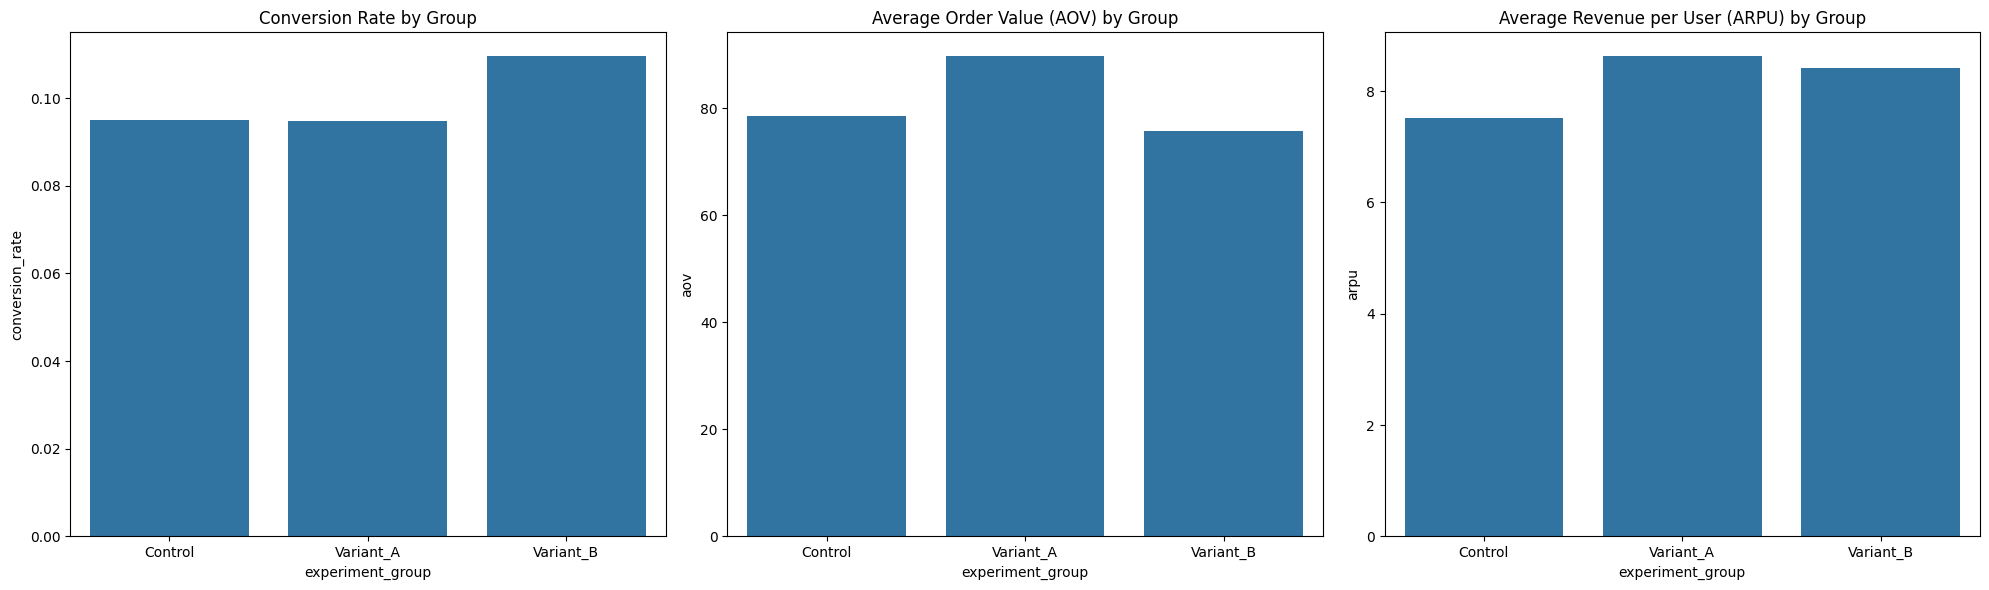

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(x=conversion_stats.index, y=conversion_stats['conversion_rate'], ax=axes[0])
axes[0].set_title('Conversion Rate by Group')

sns.barplot(x=aov_stats.index, y=aov_stats['aov'], ax=axes[1])
axes[1].set_title('Average Order Value (AOV) by Group')

sns.barplot(x=arpu_stats.index, y=arpu_stats['arpu'], ax=axes[2])
axes[2].set_title('Average Revenue per User (ARPU) by Group')

plt.tight_layout()
plt.show()

## 8. Statistical Significance Test on Continuous Metrics(Order Value)

Using Welch's T-test to compare the mean order value (gross_revenue) between the Control and Variant groups.

In [9]:
control_aov_dist = trans_with_group[trans_with_group['experiment_group'] == 'Control']['gross_revenue'].dropna()

for variant in ['Variant_A', 'Variant_B']:
    if variant in trans_with_group['experiment_group'].unique():
        variant_aov_dist = trans_with_group[trans_with_group['experiment_group'] == variant]['gross_revenue'].dropna()
        
        t_stat, p_val = stats.ttest_ind(control_aov_dist, variant_aov_dist, equal_var=False)
        print(f"AOV Significance - Control vs {variant}: p-value={p_val:.4f} ({'Significant' if p_val < 0.05 else 'Not Significant'})")

AOV Significance - Control vs Variant_A: p-value=0.2055 (Not Significant)
AOV Significance - Control vs Variant_B: p-value=0.7575 (Not Significant)


## 9. Order Value (OV) Distribution Plots

Visualizing the distribution of transaction amounts to compare Control and Variants. We use a 95th percentile cutoff for better visualization of the main distribution.

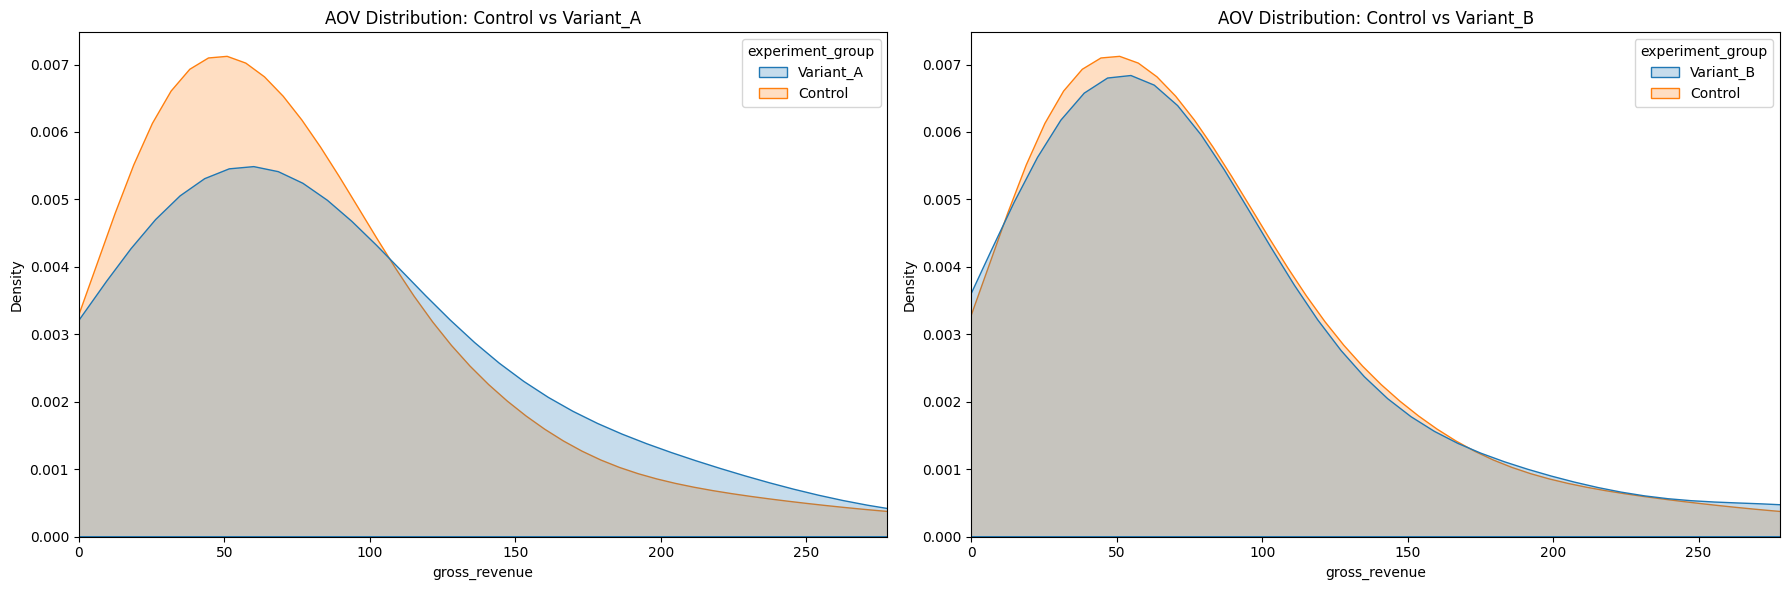

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

cutoff = trans_with_group['gross_revenue'].quantile(0.95)

# Control vs Variant_A
sns.kdeplot(data=trans_with_group[trans_with_group['experiment_group'].isin(['Control', 'Variant_A'])], 
            x='gross_revenue', hue='experiment_group', common_norm=False, ax=axes[0], fill=True)
axes[0].set_title('AOV Distribution: Control vs Variant_A')
axes[0].set_xlim(0, cutoff)

# Control vs Variant_B
sns.kdeplot(data=trans_with_group[trans_with_group['experiment_group'].isin(['Control', 'Variant_B'])], 
            x='gross_revenue', hue='experiment_group', common_norm=False, ax=axes[1], fill=True)
axes[1].set_title('AOV Distribution: Control vs Variant_B')
axes[1].set_xlim(0, cutoff)

plt.tight_layout()
plt.show()

The distribution is long-tailed, so I will do log-transformation for futher analysis.
Although t-test shows there is no significance on Order Value between control and variant groups, we can see that Variant_A has higher value on the high-value segmentation and variant_B has higher value on the low-value segmentation, so next I will perform the customer segmentation to see if there is any significance in any of these groups.


## 10. Log Transformation for OV Analysis

Since revenue data is often skewed, applying a log transformation can help normalize the distribution for the T-test.

In [24]:
# Apply log transformation to gross_revenue
trans_with_group['log_gross_revenue'] = np.log1p(trans_with_group['gross_revenue'].dropna())

print("Welch's T-test on Log-Transformed OV:")
control_log_aov = trans_with_group[trans_with_group['experiment_group'] == 'Control']['log_gross_revenue'].dropna()

for variant in ['Variant_A', 'Variant_B']:
    if variant in trans_with_group['experiment_group'].unique():
        variant_log_aov = trans_with_group[trans_with_group['experiment_group'] == variant]['log_gross_revenue'].dropna()
        
        t_stat, p_val = stats.ttest_ind(control_log_aov, variant_log_aov, equal_var=False)
        print(f"Log-AOV Significance - Control vs {variant}: p-value={p_val:.4f} ({'Significant' if p_val < 0.05 else 'Not Significant'})")

Welch's T-test on Log-Transformed OV:
Log-AOV Significance - Control vs Variant_A: p-value=0.1595 (Not Significant)
Log-AOV Significance - Control vs Variant_B: p-value=0.3554 (Not Significant)


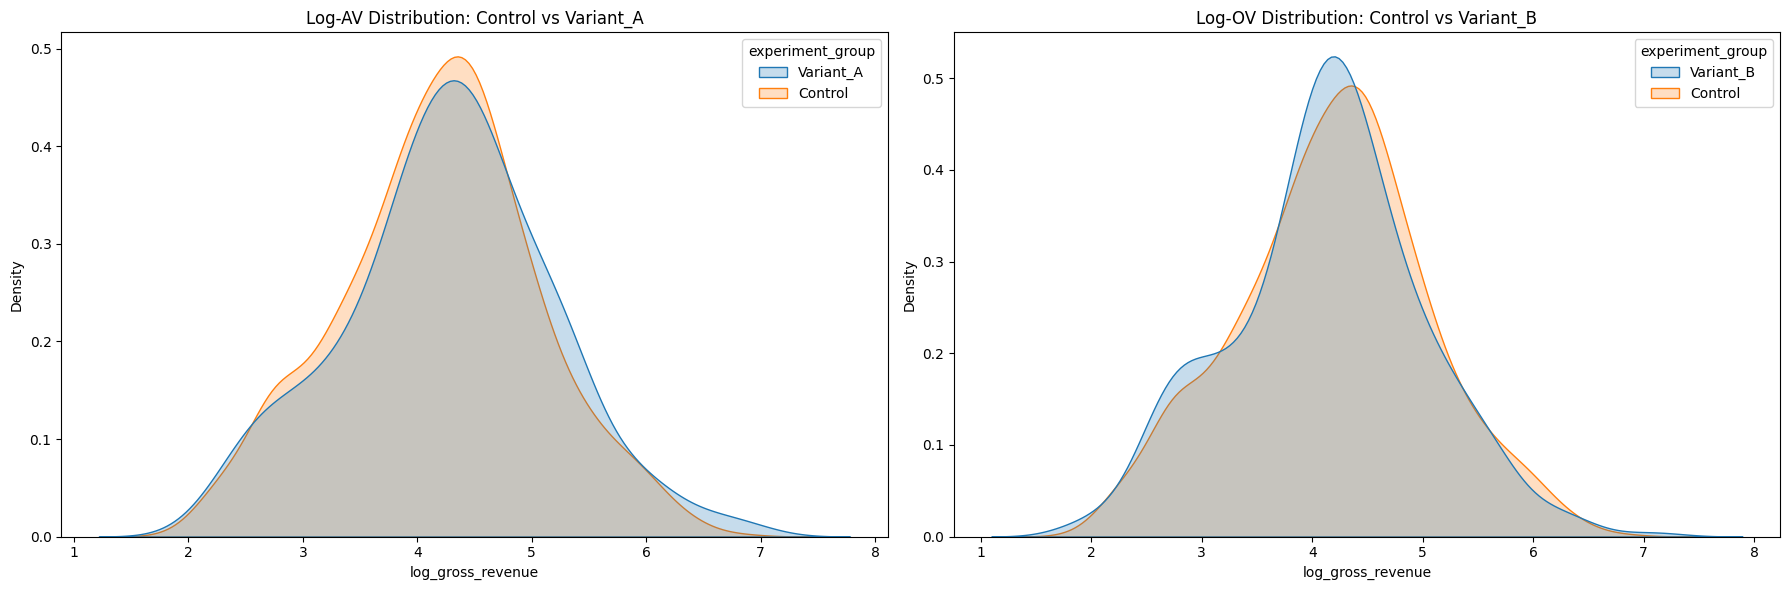

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Control vs Variant_A (Log)
sns.kdeplot(data=trans_with_group[trans_with_group['experiment_group'].isin(['Control', 'Variant_A'])], 
            x='log_gross_revenue', hue='experiment_group', common_norm=False, ax=axes[0], fill=True)
axes[0].set_title('Log-AV Distribution: Control vs Variant_A')

# Control vs Variant_B (Log)
sns.kdeplot(data=trans_with_group[trans_with_group['experiment_group'].isin(['Control', 'Variant_B'])], 
            x='log_gross_revenue', hue='experiment_group', common_norm=False, ax=axes[1], fill=True)
axes[1].set_title('Log-OV Distribution: Control vs Variant_B')

plt.tight_layout()
plt.show()

## 11. Segmented Analysis: Low vs High Spenders

Segmenting users into Low Spenders and High Spenders based on the median transaction value, and then performing the significance test on log-transformed values within each segment.

In [28]:
# Segment based on original gross_revenue (using median as threshold)
# median_spend = trans_with_group['gross_revenue'].median()
median_spend = 20
print(f"Spend Threshold: {median_spend:.2f}")

trans_with_group['spender_segment'] = np.where(trans_with_group['gross_revenue'] > median_spend, 'High Spender', 'Low Spender')

for segment in ['Low Spender', 'High Spender']:
    print(f"\n--- {segment} ---")
    segment_df = trans_with_group[trans_with_group['spender_segment'] == segment]
    control_seg = segment_df[segment_df['experiment_group'] == 'Control']['log_gross_revenue'].dropna()
    
    for variant in ['Variant_A', 'Variant_B']:
        if variant in segment_df['experiment_group'].unique():
            variant_seg = segment_df[segment_df['experiment_group'] == variant]['log_gross_revenue'].dropna()
            
            t_stat, p_val = stats.ttest_ind(control_seg, variant_seg, equal_var=False)
            print(f"{segment} Log-AOV Significance - Control vs {variant}: p-value={p_val:.4f} ({'Significant' if p_val < 0.05 else 'Not Significant'})")

Spend Threshold: 20.00

--- Low Spender ---
Low Spender Log-AOV Significance - Control vs Variant_A: p-value=0.5422 (Not Significant)
Low Spender Log-AOV Significance - Control vs Variant_B: p-value=0.6395 (Not Significant)

--- High Spender ---
High Spender Log-AOV Significance - Control vs Variant_A: p-value=0.0328 (Significant)
High Spender Log-AOV Significance - Control vs Variant_B: p-value=0.7274 (Not Significant)


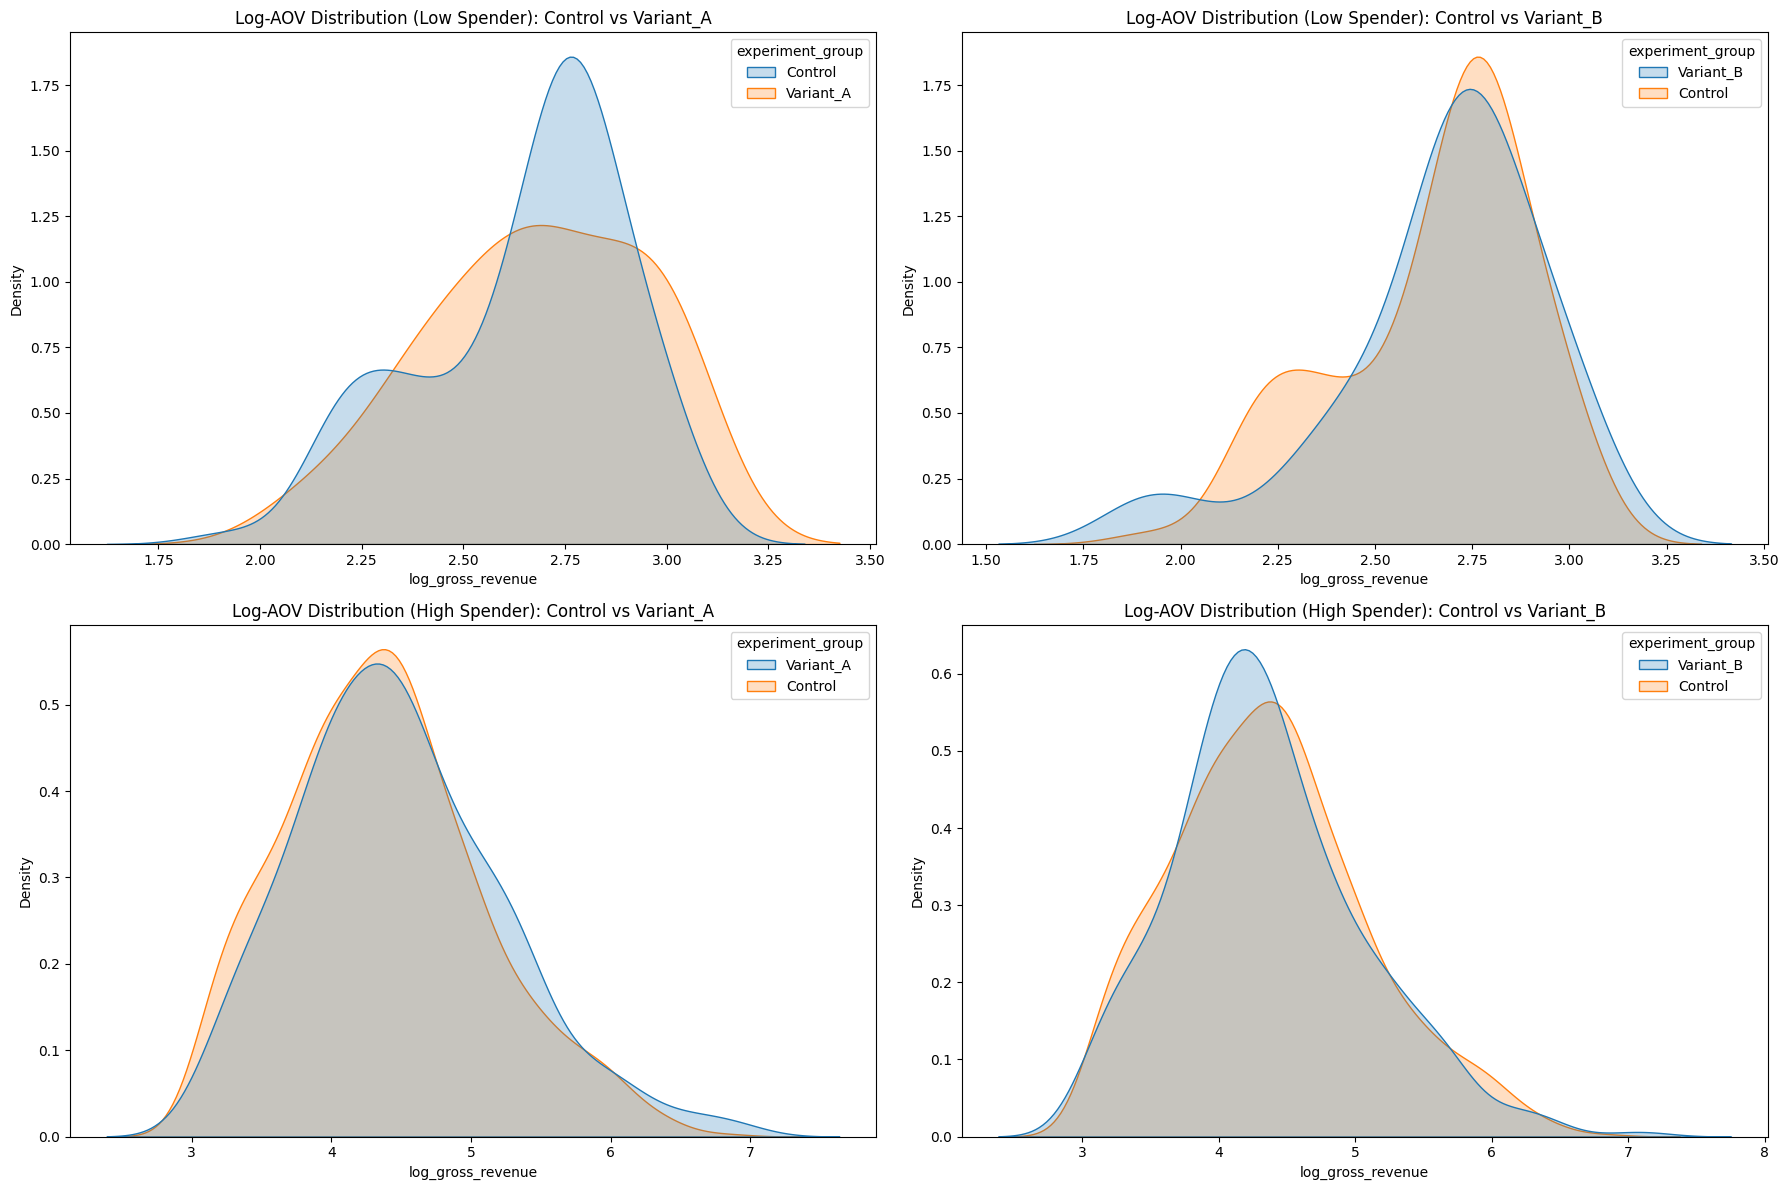

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

segments = ['Low Spender', 'High Spender']
variants = ['Variant_A', 'Variant_B']

for i, segment in enumerate(segments):
    segment_df = trans_with_group[trans_with_group['spender_segment'] == segment]
    for j, variant in enumerate(variants):
        # Comparison with Control
        plot_df = segment_df[segment_df['experiment_group'].isin(['Control', variant])]
        if not plot_df.empty:
            sns.kdeplot(data=plot_df, x='log_gross_revenue', hue='experiment_group', 
                        common_norm=False, ax=axes[i, j], fill=True)
            axes[i, j].set_title(f'Log-AOV Distribution ({segment}): Control vs {variant}')

plt.tight_layout()
plt.show()